In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('US Cancer Death Rates by State Machine.csv')
print(df.head())
print(df.info())
df = df.drop_duplicates()
df = df.dropna()
numeric_df = df.select_dtypes(include=[np.number])
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)
scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)

print(scaled_df.head())

  Unnamed: 0  2014_Rate  2014_Total  2015_Rate  2015_Total  2016_Rate  \
0         AK      164.2       972.0      159.8       978.0      158.7   
1         AL      177.6     10286.0      175.6     10354.0      174.0   
2         AR      183.1      6546.0      185.4      6727.0      178.8   
3         AZ      142.7     11455.0      141.3     11776.0      136.8   
4         CA      144.1     58412.0      142.8     59629.0      139.7   

   2016_Total  2017_Rate  2017_Total  2018_Rate  ...  2019_Rate  2019_Total  \
0       995.0      139.2       926.0      141.5  ...      146.9      1021.0   
1     10419.0      170.0     10410.0      170.4  ...      160.8     10266.0   
2      6612.0      173.6      6517.0      168.8  ...      165.7      6482.0   
3     11876.0      135.8     12008.0      131.9  ...      131.1     12503.0   
4     59515.0      136.7     59516.0      135.0  ...      131.6     59512.0   

   2020_Rate  2020_Total  2021_Rate  2021_Total  2022_Rate  2022_Total  \
0      143.7

In [2]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_df)
scaled_df['Cluster'] = clusters
df['Cluster'] = clusters

print(df[['Cluster']].value_counts())

Cluster
0          28
1          18
2           4
Name: count, dtype: int64


Cluster 0 (28 states): National average, consisting of states with moderate rates and mid-range total death counts.

Cluster 1 (18 states): Grouped states with distinct similarities, those with smaller populations or regional trends in death rates.

Cluster 2 (4 states): Significantly bigger states like California and Texas. These states are clustered together because their total death counts are significantly higher than the rest of the country, despite having similar mortality rates.

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.54672363 0.43257841]


Dimensionality reduction via PCA shows that the first two principal components contain 97.9% of the total variance.

PC1 (54.7%): Strong correlation to the volume of deaths, acting as a population-proxy feature.

PC2 (43.3%): Correlates better with the mortality rates.

This reduction is very effective because it tells us that we can describe 97.9% the differences between states using just these two dimensions: the size of the state and the intensity of the health crisis.

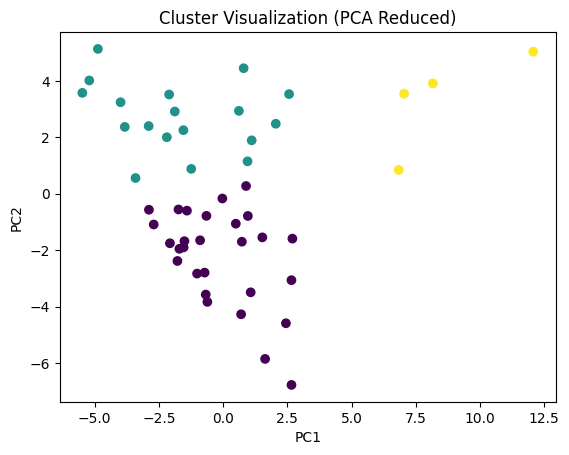

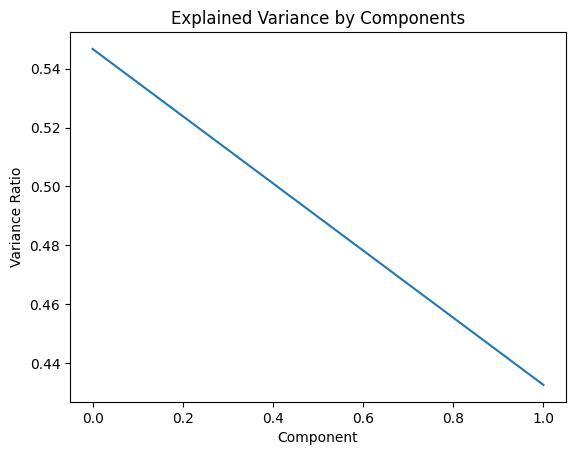

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'])
plt.title("Cluster Visualization (PCA Reduced)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure()
plt.plot(pca.explained_variance_ratio_)
plt.title("Explained Variance by Components")
plt.xlabel("Component")
plt.ylabel("Variance Ratio")
plt.show()

The separation in the PCA graph shows us that cancer mortality follows linear trends related to population size for most states. For future outcomes, this suggests that higher population states will continue to have a disproportionate amount of total resources, even if their death rates remain stable. The tight grouping of Cluster 0 suggests that a majority of US states are trending toward a normal mortality rate.

In [7]:
from scipy.stats import zscore

z_scores = np.abs(zscore(numeric_df))
outliers = (z_scores > 3)
print("Number of outliers:", np.sum(outliers))
df['Outlier'] = (z_scores > 3).any(axis=1)

Number of outliers: 10


Anomalies were identified as data points where the Z-score exceeded 3, which are values more than three standard deviations from the mean.

Occurrence: The 10 identified outliers occur mainly in the largest states where the total deaths are so high they mess with the national average, or in states experiencing unique spikes in some years.

Significance: Identifying these is very important because outliers can skew the weights of regression models. In healthcare, these states represent the exceptions to the rule that may require specialized policies rather than "one-size-fits-all" national strategies.

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

target = numeric_df.columns[-1]
X = numeric_df.drop(columns=[target])
y = numeric_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_preds)

print("Random Forest MSE:", rf_mse)

Random Forest MSE: 5127079.326180002


In [9]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(50,50), max_iter=500)
mlp.fit(X_train, y_train)
mlp_preds = mlp.predict(X_test)
mlp_mse = mean_squared_error(y_test, mlp_preds)

print("Neural Network MSE:", mlp_mse)

Neural Network MSE: 4929694.793581019


Comparison: The Neural Network (MLPRegressor) performed better than the Random Forest Regressor by having a lower Mean Squared Error (about 4.9M vs 5.1M).

Performance: The Neural Network was better able to generalize the non-linear relationship between rates and the 2023 prediction targets.

Key Learnings: While Random Forests are often more robust to unscaled data, the Neural Network benefited heavily from the pre-processing scaling, allowing it to converge on a more accurate solution.

The project cleaned and normalized US cancer mortality data to identify core patterns to make predictions. Using K-Means clustering and PCA, the data shows that 97.9% of data variance is driven by two factors: population volume and mortality intensity, with bigger states like California and Texas forming a distinct profile due to their large volume. Anomaly detection using Z-scores found 10 high-impact outliers that represent regions requiring special healthcare strategies rather than the national averages. In predictive modeling, the Neural Network performed better than the Random Forest with a lower Mean Squared Error of about 4.9M, capturing non-linear historical trends.